In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import scipy
import seaborn as sns
from synapse_counting import results_plotting

In [31]:
# loading the data
combined = pd.read_csv("datas1.csv")
combined.head(5)

,Replicate,Treatment,Speed
0,1,Control,43.69202
1,1,Control,41.85664
2,1,Control,49.11707
3,1,Control,49.79331
4,1,Control,41.54301


In [3]:
# getting in right format
ReplicateAverages = combined.groupby(["Treatment","Replicate"], as_index=False).agg({"Speed":"mean"})
ReplicateAvePivot = ReplicateAverages.pivot_table(columns="Treatment", values="Speed", index="Replicate")
ReplicateAvePivot.head(10)

Treatment,Control,Drug
Replicate,,
1,41.490610,29.573912
2,32.638003,22.317653
3,20.622035,12.898156


In [4]:
# statistics
statistic, pvalue = scipy.stats.ttest_rel(ReplicateAvePivot["Control"], ReplicateAvePivot["Drug"])
print("pvalue:", pvalue, "\n" "& t-statistic:", statistic)

mean = ReplicateAvePivot.mean()
print(mean)
sem = ReplicateAvePivot.sem()
print(sem)

pvalue: 0.01463875293852146 
& t-statistic: 8.174075882056934
Treatment
Control    31.583549
Drug       21.596574
dtype: float64
Treatment
Control    6.047266
Drug       4.827359
dtype: float64


In [24]:
import numpy as np
import scipy.stats as stats

# Data from the table
treatment_data = [41.490610, 32.638003, 20.622035]
control_data = [29.573912, 22.317653, 12.898156]

# Calculate Cohen's d
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_var = ((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2)
    d = (np.mean(x) - np.mean(y)) / np.sqrt(pooled_var)
    return d

cohen_d_result = cohen_d(treatment_data, control_data)

print("Cohen's d:", cohen_d_result)

Cohen's d: 1.0538372223629877


In [19]:
import numpy as np

def hochberg_correction(p_values, alpha=0.05):
    """
    Apply Hochberg correction to a list of P-values.
    
    Parameters:
        p_values (list or array-like): List of P-values to adjust.
        alpha (float): Significance level (default is 0.05).
    
    Returns:
        list: Adjusted P-values.
        list: Boolean list indicating which adjusted P-values are below the significance level.
    """
    p_values = np.array(p_values)
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p_values = p_values[sorted_indices]
    
    # Compute adjusted P-values
    adjusted_p_values = np.zeros(m)
    for i in range(m):
        adjusted_p_values[sorted_indices[i]] = sorted_p_values[i] * (m - i)
    
    # Control FWER
    reject_null = adjusted_p_values <= alpha
    return adjusted_p_values.tolist(), reject_null.tolist()

# Example usage
p_values = [0.912095, ]
adjusted_p_values, reject_null = hochberg_correction(p_values)
print("Hochberg Adjusted P-values:", adjusted_p_values)
print("Reject Null Hypothesis:", reject_null)


Hochberg Adjusted P-values: [2.736285571728816, 16.10685719878442, 16.662164815468753, 16.86256927798025, 7.281732066291867, 15.488606734067638, 15.938974464596404, 15.57696423286704, 15.838847798002067, 15.407225296509935, 5.9108708787228315, 16.240496147404034, 15.839593642665157, 14.039165665499523, 12.024443979593434, 14.444820400133926, 7.2906810343969575, 1.6448440913483149, 15.578173960315926, 0.9982646716611964, 16.634527986891225, 16.253990516670356, 12.166362254568623, 2.5326015427529907, 11.36154968684392, 4.389914104771043, 11.952284296875202, 16.784669676735817, 13.525013690237081, 3.626743899096556, 13.077765336146884, 17.37722126749224, 15.43617531725407, 15.753392670811543, 11.456968613026039, 16.178449479906938, 16.476258546757307, 16.025651078212302, 9.568516484765443, 1.7518389580073326, 7.968530400030958, 16.858644148098755, 10.592192965478969, 14.991417321583711, 7.709350113251922, 10.251503549590378, 15.663492257662263, 16.134744036371938, 16.852820613211108, 16.4

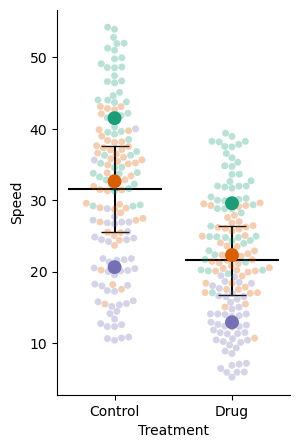

In [5]:
# plotting

# Create a Figure object
fig, ax = plt.subplots(figsize=(3, 5))

sns.despine()

# Swarm plot for individual data points
sns.swarmplot(x="Treatment", y="Speed", hue="Replicate", alpha=0.3, palette="Dark2", data=combined, ax=ax)

# Swarm plot for replicate averages
ax = sns.swarmplot(x="Treatment", y="Speed", hue="Replicate", size=10, palette="Dark2", data=ReplicateAverages, ax=ax)

# line as mean
for i, m in enumerate(mean):
    plt.hlines(m, i - 0.4, i + 0.4, color='black', linewidth=1.5)

# rest of error bar
plt.errorbar(range(len(mean)), mean, yerr = sem, capsize = 10, color='black', alpha=1,
             linewidth=1.5, linestyle='', marker='_')

# Remove legend
ax.legend_.remove()

# exporting the graph
plt.savefig("seaborn_plot.png", dpi = 300)    

plt.show()

In [ ]:
cmap = sns.choose_colorbrewer_palette("q")

/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_85219/250930693.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Group', y='Value', data=df,
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_85219/250930693.py:26: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(x='Group', y='Value', data=df,
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_85219/250930693.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Group', y='Value', data=df,


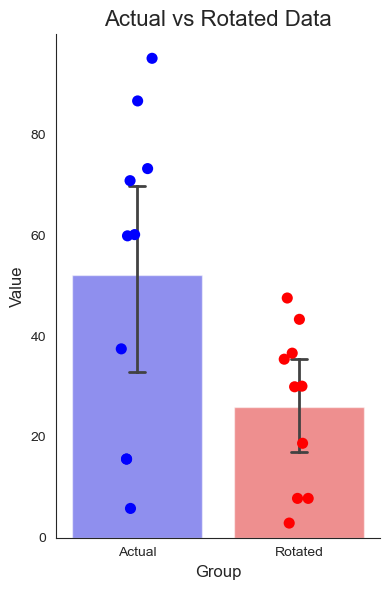

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate data
n_points = 10
actual_data = np.random.rand(n_points) * 100
rotated_data = actual_data * 0.5  # 50% smaller

# Create a DataFrame
df = pd.DataFrame({
    'Value': np.concatenate([actual_data, rotated_data]),
    'Group': ['Actual'] * n_points + ['Rotated'] * n_points,
    'Index': np.tile(np.arange(n_points), 2)
})

# Set up the plot
plt.figure(figsize=(4, 6))
sns.set_style("white")  # Changed from "whitegrid" to "white"

# Create the bar plot
sns.barplot(x='Group', y='Value', data=df, 
            palette=['blue', 'red'], alpha=0.5,
            capsize=0.1, errwidth=2)

# Overlay the individual data points
sns.stripplot(x='Group', y='Value', data=df,
              palette=['blue', 'red'], size=8, jitter=True)

# Customize the plot
plt.title('Actual vs Rotated Data', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Value', fontsize=12)

# Remove top and right spines
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()